# Credit Risk — Probability of Default (PD)

A compact, leakage-aware pipeline for estimating corporate **Probability of Default (PD)**:
data-quality assessment → feature engineering → a customer-level train/test split → binning,
**Weight of Evidence (WoE)** and feature selection (Information Value + correlation) →
logistic, probit and linear models, benchmarked against an experts' scorecard and a
segmentation check.

**Design choices**
- Every fitted step (binning, IV, correlation pruning) is learned on the **training set only** and then applied to the test set, to avoid information leakage.
- The data is panel-structured — one customer can appear in several assessment years — so the split is performed **by customer**, never by row.
- All models share a single predictor representation (the WoE-transformed features).

**Data.** Corporate credit assessments (≈5,800 firm-year records, 2000–2008). The target
`DEFAULT_FLAG` has a base default rate of ~9.6%. Predictors include six expert assessment
dimensions (10–90 scale, 90 = healthiest), turnover, industry and a holding-group flag.

## Setup

Install dependencies, import the libraries, and set the data path and a global random seed
for reproducibility.

In [1]:
# Dependencies (Colab / fresh environments)
!pip install scorecardpy xlrd tabulate -q
%matplotlib inline

import warnings
warnings.simplefilter("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scorecardpy as sc
import statsmodels.api as sm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Path to the data file (relative; on Colab use e.g. '/content/credit-risk_data.xls')
DATA_PATH    = "credit-risk_data.xls"  # adjust if needed
RANDOM_STATE = 7

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 1. Data loading & quality assessment

Load the raw assessments, inspect summary statistics and missing values, then drop the few
fully-empty export rows and cast the target to an integer.

Shape: (5804, 12)
|                       |              min |            25% |            50% |           mean |            75% |            max |   NA_count |
|:----------------------|-----------------:|---------------:|---------------:|---------------:|---------------:|---------------:|-----------:|
| CUSTOMER_ID           | 189033           |    1.56191e+06 |    1.5942e+06  |    1.99738e+06 |    2.41393e+06 |    5.10289e+06 |          3 |
| ASSESSMENT_YEAR       |   2000           | 2004           | 2006           | 2005.86        | 2008           | 2008           |          1 |
| PRODUCT_DEMAND        |     10           |   54           |   59           |   57.75        |   62           |   90           |          3 |
| OWNERS_MANAGEMENT     |     10           |   55           |   60           |   58.91        |   65           |   90           |          3 |
| ACCESS_CREDIT         |     10           |   50           |   55           |   55.86        |   60           |   90       

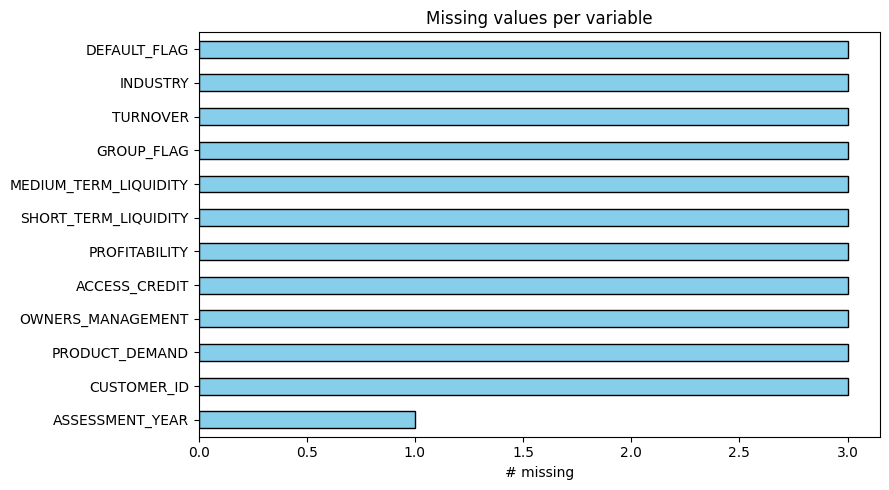


After cleaning: (5801, 12) | default rate = 0.096


In [2]:
df = pd.read_excel(DATA_PATH)
print("Shape:", df.shape)

# Summary statistics + missing-value counts
summary = df.describe().T
summary["NA_count"] = df.isnull().sum()
print(summary[["min", "25%", "50%", "mean", "75%", "max", "NA_count"]].round(2).to_markdown())

# Missing-values chart
df.isnull().sum().sort_values().plot(kind="barh", figsize=(9, 5),
                                     color="#87CEEB", edgecolor="black")
plt.title("Missing values per variable")
plt.xlabel("# missing"); plt.tight_layout(); plt.show()

# Cleaning:
# Missing values are concentrated in a few fully-empty export rows,
# so we drop records without CUSTOMER_ID and cast the target to int.
df = df[df["CUSTOMER_ID"].notna()].copy()
df["DEFAULT_FLAG"] = df["DEFAULT_FLAG"].astype(int)
print(f"\nAfter cleaning: {df.shape} | default rate = {df['DEFAULT_FLAG'].mean():.3f}")

## 2. Feature engineering & train/test split

Derive two customer-history features from the panel (cumulative assessment count and prior
defaults), then split **by customer** so that no client's years land on both sides of the split.

In [3]:
# --- Customer-history features (customer-year panel) ---
df = df.sort_values(["CUSTOMER_ID", "ASSESSMENT_YEAR"]).reset_index(drop=True)

# Number of assessments seen so far for each customer
df["Number_of_credits"] = df.groupby("CUSTOMER_ID").cumcount() + 1

# Number of defaults in strictly prior years
df["Number_of_default_before_today"] = (
    df.groupby("CUSTOMER_ID")["DEFAULT_FLAG"]
      .apply(lambda s: s.shift(1).fillna(0).cumsum())
      .reset_index(level=0, drop=True)
      .astype(int)
)

# --- Split BY CUSTOMER (not by row) ---
# The data is panel-structured: the same customer appears across several years. A random
# row-level split would place a customer's years on both sides (leakage). GroupShuffleSplit
# keeps all rows of a given customer on the same side.
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df, df["DEFAULT_FLAG"], groups=df["CUSTOMER_ID"]))

drop_ids = ["CUSTOMER_ID", "ASSESSMENT_YEAR"]   # identifiers, not predictors
train = df.iloc[tr_idx].drop(columns=drop_ids).reset_index(drop=True)
test  = df.iloc[te_idx].drop(columns=drop_ids).reset_index(drop=True)

print(f"train {train.shape} | default rate {train['DEFAULT_FLAG'].mean():.3f}")
print(f"test  {test.shape} | default rate {test['DEFAULT_FLAG'].mean():.3f}")

train (4638, 12) | default rate 0.092
test  (1163, 12) | default rate 0.112


## 3. Exploratory data analysis (train only)

Distributions of the continuous predictors, the industry breakdown and the (imbalanced)
target — computed on the training set only.

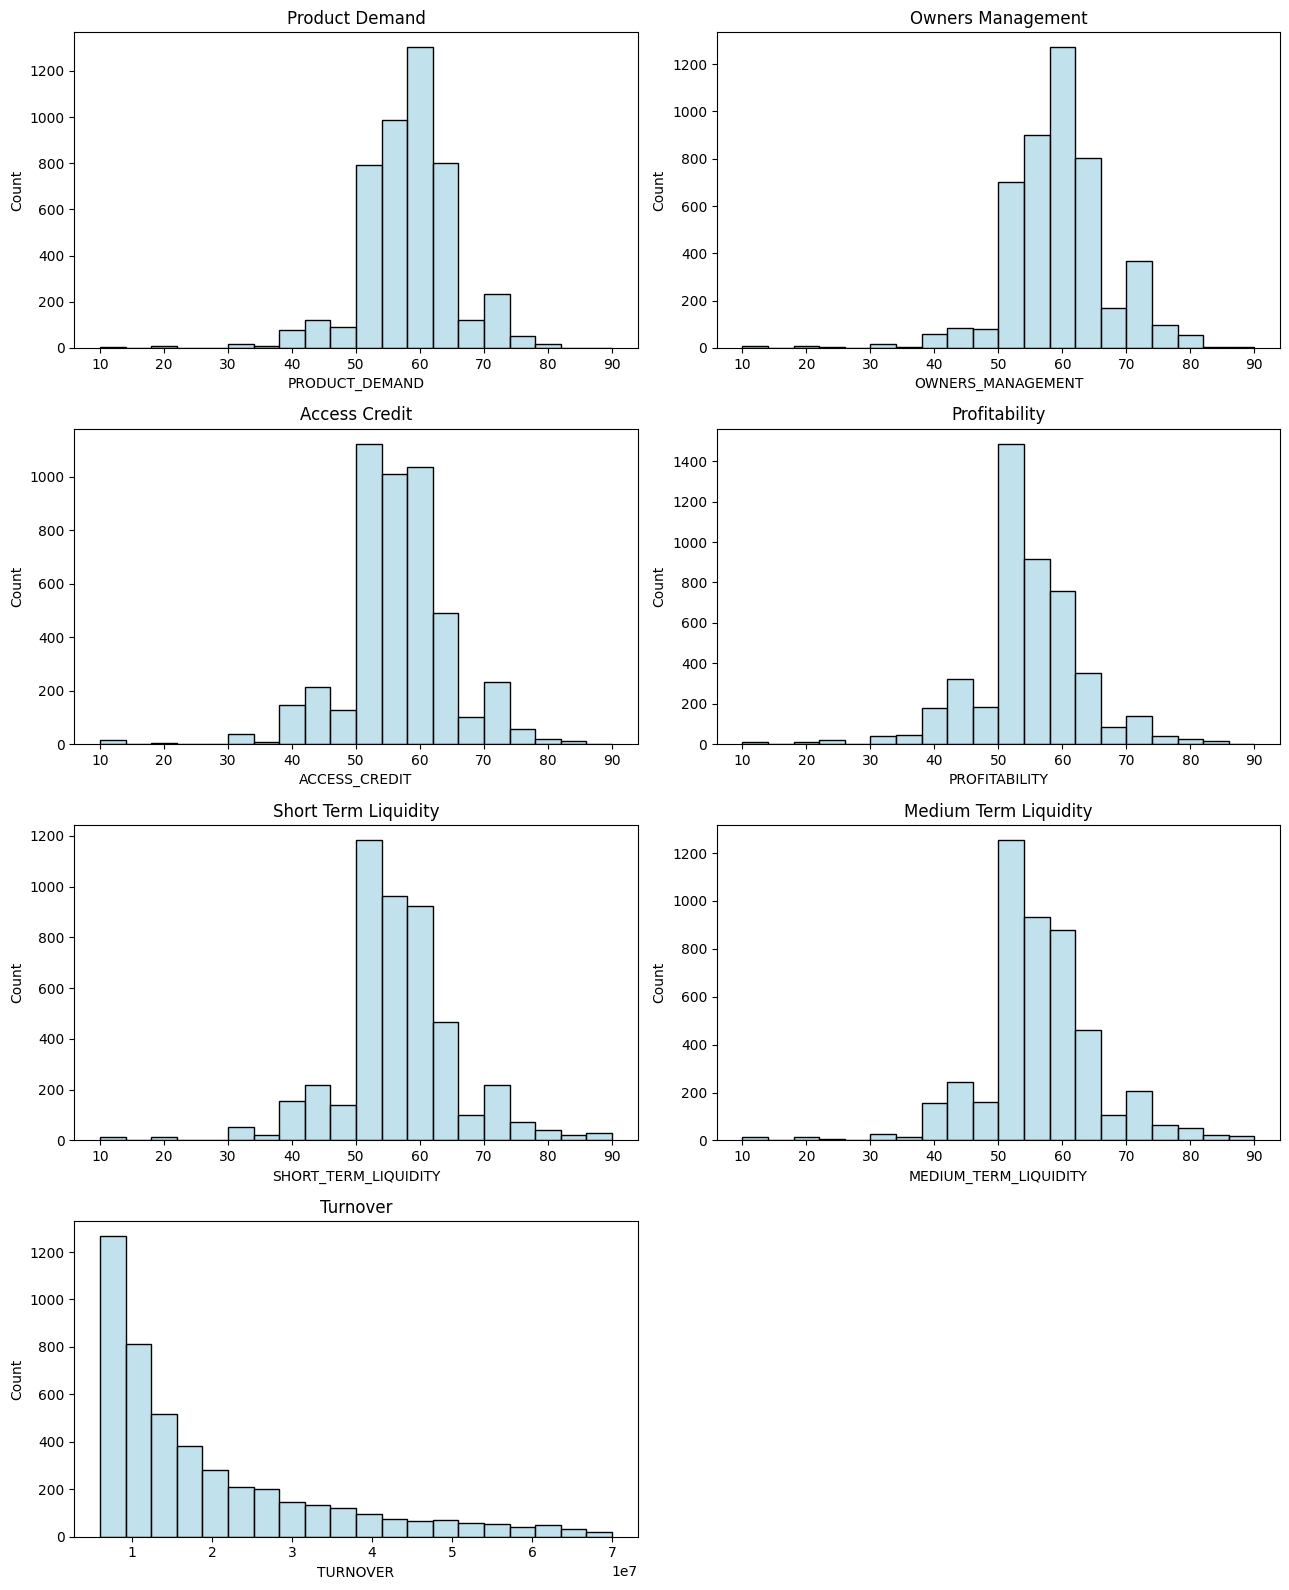

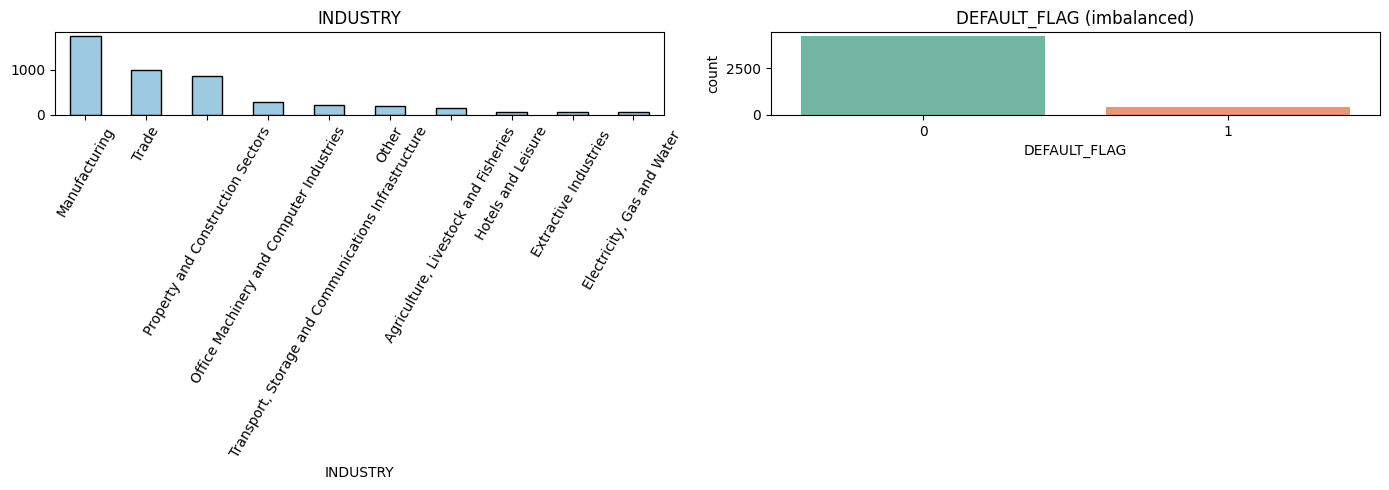

In [4]:
# Continuous variables auto-detected (numeric, many distinct values, not flags)
num_vars = [c for c in train.select_dtypes("number").columns
            if train[c].nunique() > 10 and "FLAG" not in c]

n_rows = -(-len(num_vars) // 2)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 4 * n_rows))
for ax, v in zip(axes.flatten(), num_vars):
    sns.histplot(train[v], bins=20, color="#ADD8E6", edgecolor="black", ax=ax)
    ax.set_title(v.replace("_", " ").title())
for ax in axes.flatten()[len(num_vars):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

# Industry breakdown + target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train["INDUSTRY"].value_counts().plot(kind="bar", ax=axes[0],
                                      color="#9ECAE1", edgecolor="black")
axes[0].set_title("INDUSTRY"); axes[0].tick_params(axis="x", rotation=60)
sns.countplot(data=train, x="DEFAULT_FLAG", hue="DEFAULT_FLAG",
              palette=["#66C2A5", "#FC8D62"], legend=False, ax=axes[1])
axes[1].set_title("DEFAULT_FLAG (imbalanced)")
plt.tight_layout(); plt.show()

## 4. Binning, WoE & feature selection

Supervised binning maps each predictor to its Weight of Evidence; numeric and categorical
variables are handled uniformly. Selection runs on the same WoE representation the models use:
keep variables with Information Value > 0.1, drop zero-variance columns, then prune one of each
pair of WoE features correlated above 0.75. All steps are fitted on train only.

[INFO] creating woe binning ...


| variable                       |   info_value |
|:-------------------------------|-------------:|
| PRODUCT_DEMAND                 |  4.99331     |
| ACCESS_CREDIT                  |  2.71719     |
| OWNERS_MANAGEMENT              |  2.36428     |
| SHORT_TERM_LIQUIDITY           |  2.31203     |
| MEDIUM_TERM_LIQUIDITY          |  2.05769     |
| PROFITABILITY                  |  1.92467     |
| Number_of_default_before_today |  0.881467    |
| Number_of_credits              |  0.274098    |
| INDUSTRY                       |  0.261228    |
| TURNOVER                       |  0.075892    |
| GROUP_FLAG                     |  0.000254444 |


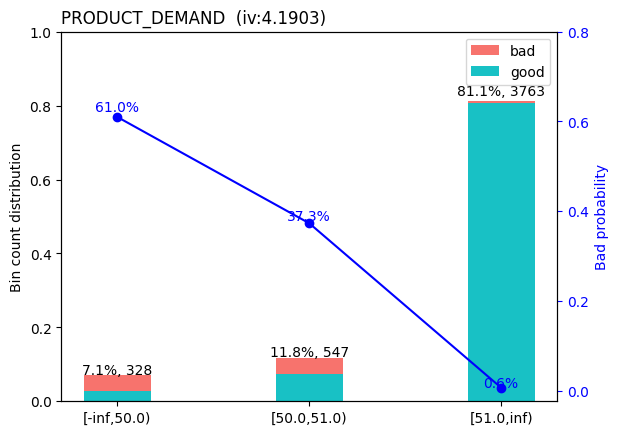

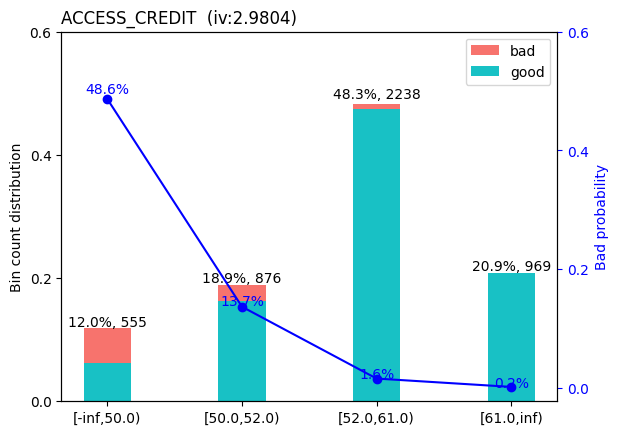

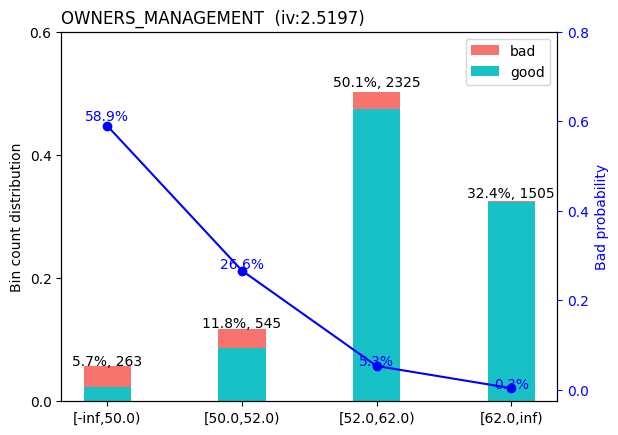

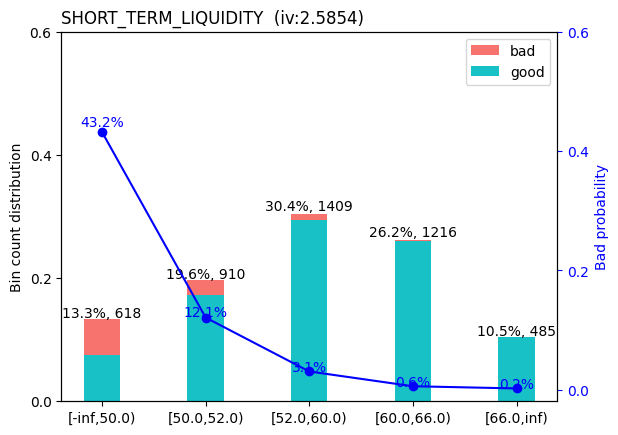

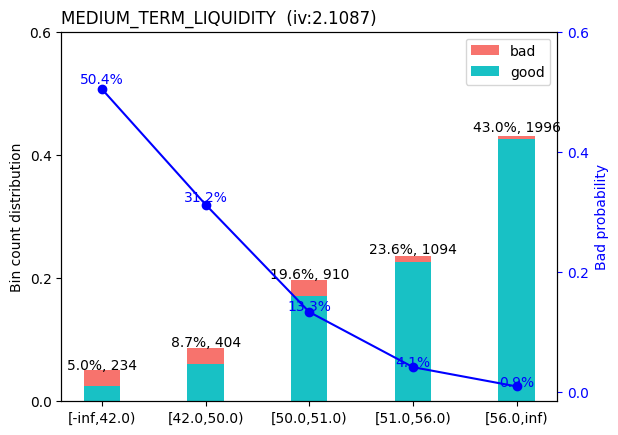

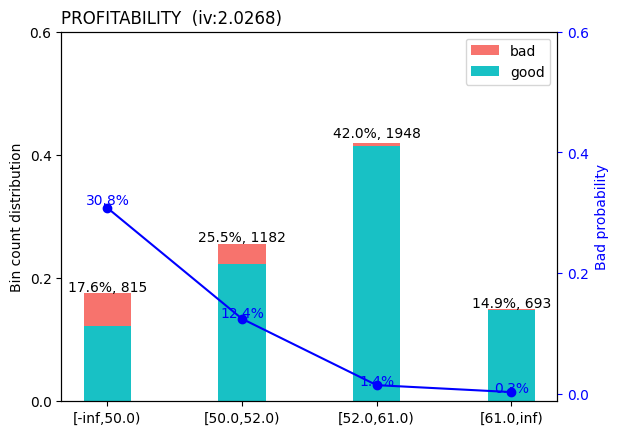

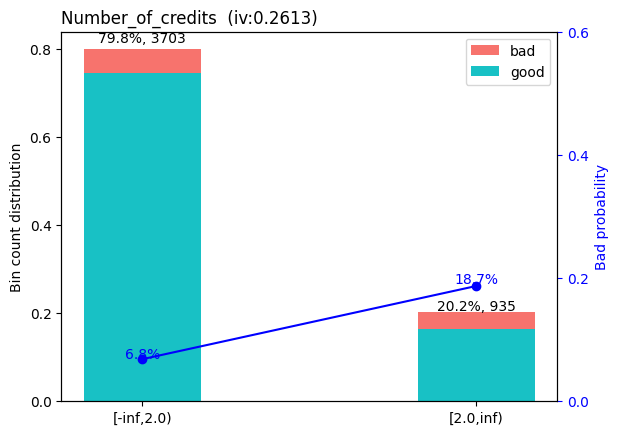

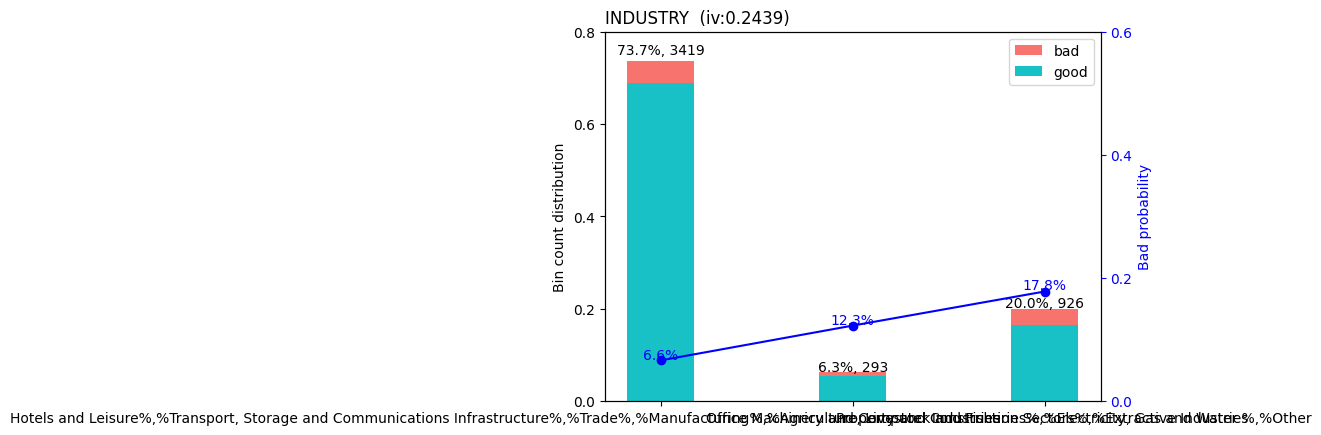

[INFO] converting into woe values ...
[INFO] converting into woe values ...


Constant WoE columns dropped: ['Number_of_default_before_today_woe']
Correlated columns dropped (>0.75): ['ACCESS_CREDIT_woe']


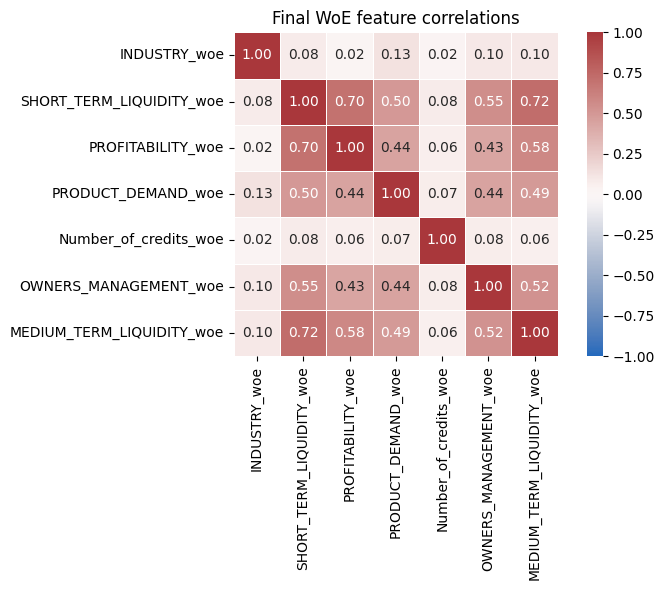


Final features (7): ['INDUSTRY_woe', 'SHORT_TERM_LIQUIDITY_woe', 'PROFITABILITY_woe', 'PRODUCT_DEMAND_woe', 'Number_of_credits_woe', 'OWNERS_MANAGEMENT_woe', 'MEDIUM_TERM_LIQUIDITY_woe']


In [5]:
# 4a. Bins fitted on TRAIN only
bins = sc.woebin(train, y="DEFAULT_FLAG", count_distr_limit=0.05, no_cores=1)

# 4b. Information Value per variable; keep IV > 0.1
iv = sc.iv(train, y="DEFAULT_FLAG").sort_values("info_value", ascending=False)
print(iv.to_markdown(index=False))
keep = iv.loc[iv["info_value"] > 0.1, "variable"].tolist()

# WoE plots of the selected variables
for v in keep:
    if len(bins[v]) > 1:
        sc.woebin_plot({v: bins[v]}); plt.show()

# 4c. WoE transform: bins learned on train, applied to both train and test (no leakage)
train_woe = sc.woebin_ply(train[keep + ["DEFAULT_FLAG"]], bins, to="woe", no_cores=1)
test_woe  = sc.woebin_ply(test[keep  + ["DEFAULT_FLAG"]], bins, to="woe", no_cores=1)
woe_cols  = [c for c in train_woe.columns if c.endswith("_woe")]

# 4d. Drop zero-variance WoE columns (no information, break estimation)
const_cols = [c for c in woe_cols if train_woe[c].nunique() <= 1]
if const_cols:
    print("Constant WoE columns dropped:", const_cols)
woe_cols = [c for c in woe_cols if c not in const_cols]

# 4e. Correlation pruning (replicates caret::findCorrelation)
def find_correlated(corr, cutoff=0.75):
    a = corr.abs().copy()
    np.fill_diagonal(a.values, np.nan)
    drop = []
    while True:
        m = a.max().max()
        if pd.isna(m) or m <= cutoff:
            break
        c1, c2 = a.stack().idxmax()                 # most correlated pair
        d = c1 if a[c1].mean() >= a[c2].mean() else c2
        drop.append(d)
        a = a.drop(index=d, columns=d)
    return drop

drop_corr = find_correlated(train_woe[woe_cols].corr(), cutoff=0.75)
print("Correlated columns dropped (>0.75):", drop_corr)
features = [c for c in woe_cols if c not in drop_corr]

plt.figure(figsize=(8, 6))
sns.heatmap(train_woe[features].corr(), annot=True, fmt=".2f", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title("Final WoE feature correlations")
plt.tight_layout(); plt.show()

# Final design matrices
X_train = sm.add_constant(train_woe[features])
X_test  = sm.add_constant(test_woe[features])
y_train = train_woe["DEFAULT_FLAG"]
y_test  = test_woe["DEFAULT_FLAG"]
print(f"\nFinal features ({len(features)}): {features}")

## 5. PD models

Three candidate specifications are fitted on the WoE features and evaluated on the held-out
test set: logistic regression (the primary model), probit, and a linear probability model.

### 5.1 Logistic regression (primary model)

Fit the logit, print the model summary, then report AUC/Gini with the test-set ROC curve and
confusion matrix.

Optimization terminated successfully.
         Current function value: 0.129072
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                 4638
Model:                          Logit   Df Residuals:                     4630
Method:                           MLE   Df Model:                            7
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                  0.5806
Time:                        00:32:04   Log-Likelihood:                -598.64
converged:                       True   LL-Null:                       -1427.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.2317      0.098    -22.739      0.000      -2.

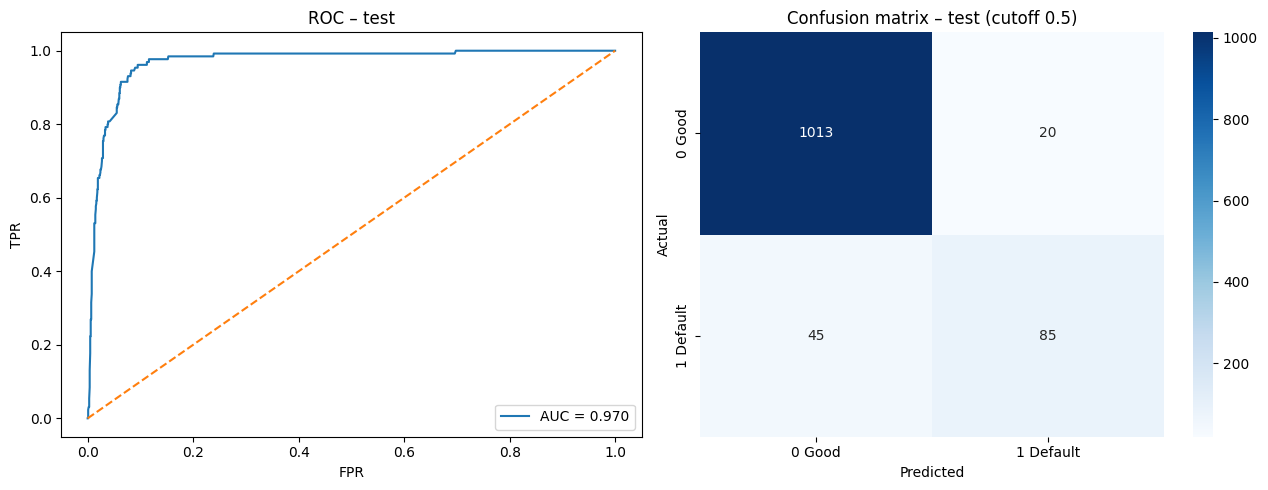

In [6]:
logit = sm.Logit(y_train, X_train).fit()
print(logit.summary())

def evaluate(model, X, y, label):
    # Predict, then print AUC and Gini = 2*AUC - 1
    p = model.predict(X)
    auc = roc_auc_score(y, p)
    print(f"{label}: AUC = {auc:.4f} | Gini = {2 * auc - 1:.4f}")
    return p, auc

p_tr, _      = evaluate(logit, X_train, y_train, "Train")
p_te, auc_te = evaluate(logit, X_test,  y_test,  "Test ")

# ROC (test) + confusion matrix (test, cutoff 0.5)
fpr, tpr, _ = roc_curve(y_test, p_te)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, label=f"AUC = {auc_te:.3f}")
ax[0].plot([0, 1], [0, 1], "--")
ax[0].set_title("ROC – test"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()

cm = confusion_matrix(y_test, (p_te >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["0 Good", "1 Default"], yticklabels=["0 Good", "1 Default"])
ax[1].set_title("Confusion matrix – test (cutoff 0.5)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

### 5.2 Probit model

The same specification under a probit link, with marginal effects for interpretability.

Optimization terminated successfully.
         Current function value: 0.127717
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:           DEFAULT_FLAG   No. Observations:                 4638
Model:                         Probit   Df Residuals:                     4630
Method:                           MLE   Df Model:                            7
Date:                Sun, 14 Jun 2026   Pseudo R-squ.:                  0.5850
Time:                        00:32:04   Log-Likelihood:                -592.35
converged:                       True   LL-Null:                       -1427.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.1792      0.047    -24.913      0.000      -1.

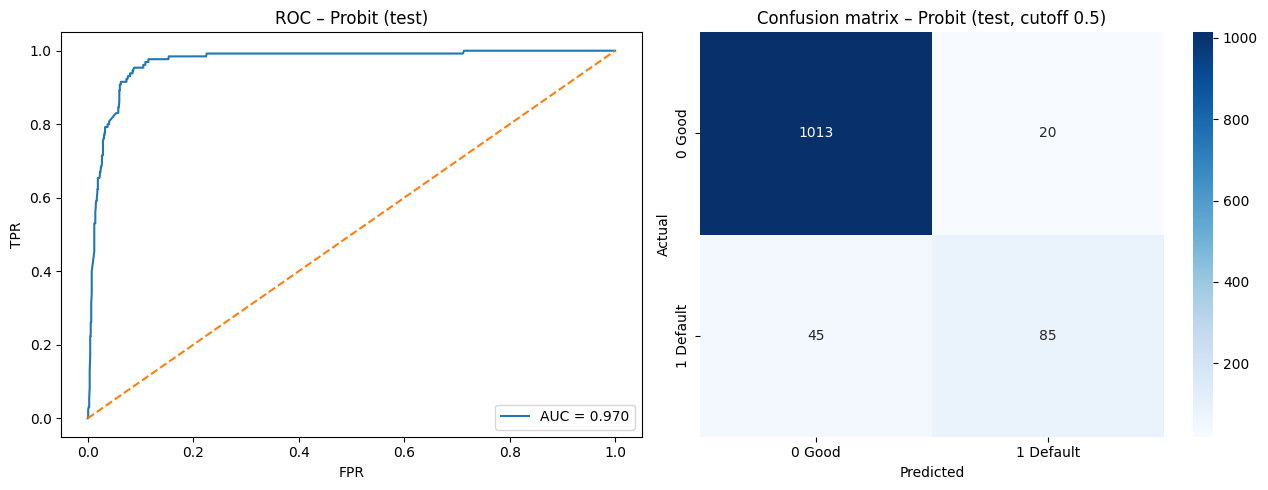

In [7]:
probit = sm.Probit(y_train, X_train).fit()
print(probit.summary())
print(probit.get_margeff().summary())          # marginal effects

evaluate(probit, X_train, y_train, "Train")
p_te, auc_te = evaluate(probit, X_test, y_test, "Test ")

# ROC + confusion matrix – probit (test, cutoff 0.5)
fpr, tpr, _ = roc_curve(y_test, p_te)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, label=f"AUC = {auc_te:.3f}")
ax[0].plot([0, 1], [0, 1], "--")
ax[0].set_title("ROC – Probit (test)"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()

cm = confusion_matrix(y_test, (p_te >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["0 Good", "1 Default"], yticklabels=["0 Good", "1 Default"])
ax[1].set_title("Confusion matrix – Probit (test, cutoff 0.5)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

# Logit and probit on WoE features give almost identical AUC/Gini. We pick logit: its
# coefficients are interpretable as log-odds ratios and it is the regulatory standard.

### 5.3 Linear probability model (LPM / OLS)

A linear baseline. We track the share of fitted probabilities falling outside [0, 1] — the
main reason the LPM is unsuitable as a PD model.

                            OLS Regression Results                            
Dep. Variable:           DEFAULT_FLAG   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     511.6
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        00:32:05   Log-Likelihood:                 498.06
No. Observations:                4638   AIC:                            -980.1
Df Residuals:                    4630   BIC:                            -928.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

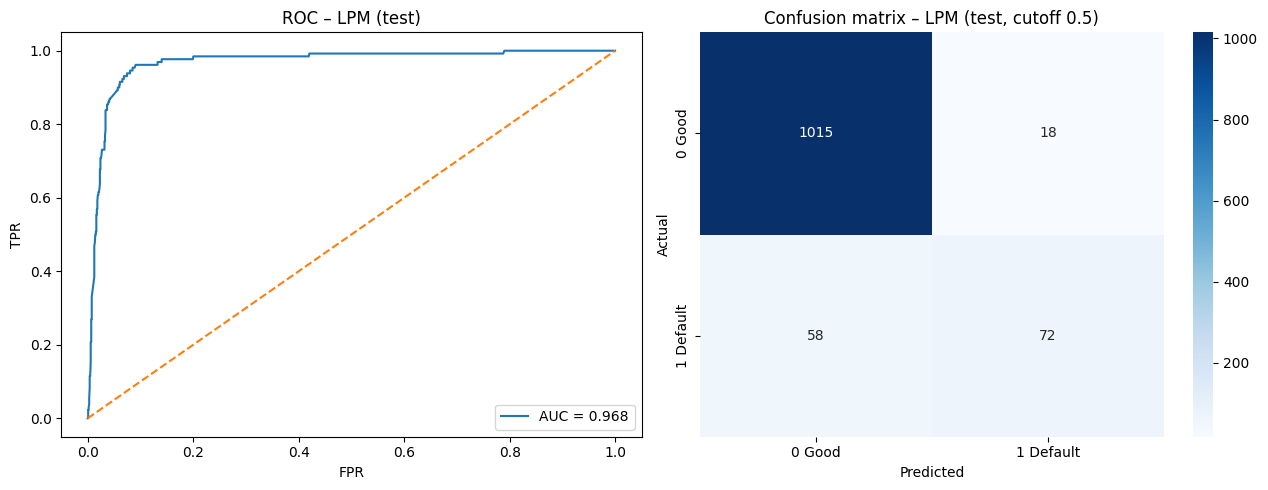

In [8]:
lpm = sm.OLS(y_train, X_train).fit()
print(lpm.summary())

evaluate(lpm, X_train, y_train, "Train")
p_te, _ = evaluate(lpm, X_test, y_test, "Test ")

# Main LPM flaw: predictions outside [0, 1]
oob = int(((p_te < 0) | (p_te > 1)).sum())
print(f"\nOut-of-bounds predictions: {oob}/{len(p_te)} ({oob / len(p_te):.1%})")
# A high share of out-of-[0,1] predictions is the key argument against deploying the LPM
# as a PD model (a probability must lie in [0, 1]).

# ROC + confusion matrix – LPM (test, cutoff 0.5)
fpr, tpr, _ = roc_curve(y_test, p_te)
auc_te = roc_auc_score(y_test, p_te)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(fpr, tpr, label=f"AUC = {auc_te:.3f}")
ax[0].plot([0, 1], [0, 1], "--")
ax[0].set_title("ROC – LPM (test)"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()

cm = confusion_matrix(y_test, (p_te >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=["0 Good", "1 Default"], yticklabels=["0 Good", "1 Default"])
ax[1].set_title("Confusion matrix – LPM (test, cutoff 0.5)")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 6. Benchmark against the experts' model

A fixed expert scorecard: each firm's Score is a weighted average of the six assessment
dimensions, mapped to a PD via `PD = 1 / (1 + exp(-0.1 · Score))`. The weights are
PRODUCT_DEMAND 0.20, OWNERS_MANAGEMENT 0.10, ACCESS_CREDIT 0.10, PROFITABILITY 0.15,
SHORT_TERM_LIQUIDITY 0.25, MEDIUM_TERM_LIQUIDITY 0.20. Because the dimensions are scored
10–90 with 90 = healthiest, the orientation of this score is worth checking explicitly.

### 6.1 Score and implied PD

Compute the experts' Score and PD on the test set and inspect the implied PD distribution
against the observed default rate.

In [9]:
# Experts' model: Score and implied PD
expert_weights = {
    "PRODUCT_DEMAND":        0.20,  # PRODUCT AND DEMAND
    "OWNERS_MANAGEMENT":     0.10,  # QUALITY OF MANAGEMENT
    "ACCESS_CREDIT":         0.10,  # ACCESS TO CREDIT
    "PROFITABILITY":         0.15,  # PROFITABILITY
    "SHORT_TERM_LIQUIDITY":  0.25,  # ABILITY TO PAY
    "MEDIUM_TERM_LIQUIDITY": 0.20,  # SOLVENCY
}
assert abs(sum(expert_weights.values()) - 1.0) < 1e-9, "Weights do not sum to 1"

def expert_score(frame):
    # Score = weighted average of the raw expert ratings
    return sum(frame[col] * w for col, w in expert_weights.items())

def expert_pd(frame):
    # Formula exactly as specified in the assignment
    return 1.0 / (1.0 + np.exp(-0.1 * expert_score(frame)))

# Computed on the test set (same rows as logit)
score_test = expert_score(test)
pd_expert  = expert_pd(test)
valid      = pd_expert.notna()          # guard against NaNs

print("Experts' PD distribution (test):")
print(pd_expert.describe().round(4).to_markdown())
print(f"\nObserved default rate (test) = {test['DEFAULT_FLAG'].mean():.4f}")

# Orientation check: mean Score by default class
print("\nMean Score by DEFAULT_FLAG (test):")
print(test.assign(Score=score_test).groupby("DEFAULT_FLAG")["Score"].mean().round(2).to_markdown())

Experts' PD distribution (test):
|       |         0 |
|:------|----------:|
| count | 1163      |
| mean  |    0.9947 |
| std   |    0.0127 |
| min   |    0.7311 |
| 25%   |    0.9945 |
| 50%   |    0.9961 |
| 75%   |    0.9976 |
| max   |    0.9997 |

Observed default rate (test) = 0.1118

Mean Score by DEFAULT_FLAG (test):
|   DEFAULT_FLAG |   Score |
|---------------:|--------:|
|              0 |   57.19 |
|              1 |   46.12 |


### 6.2 Discrimination: logit vs experts

Compare the ranking power (AUC/Gini) of the logit and the experts' PD on a common set of rows.

Logit   : AUC = 0.9698 | Gini = 0.9395
Experts : AUC = 0.0674 | Gini = -0.8653
Experts (orientation-corrected): AUC = 0.9326


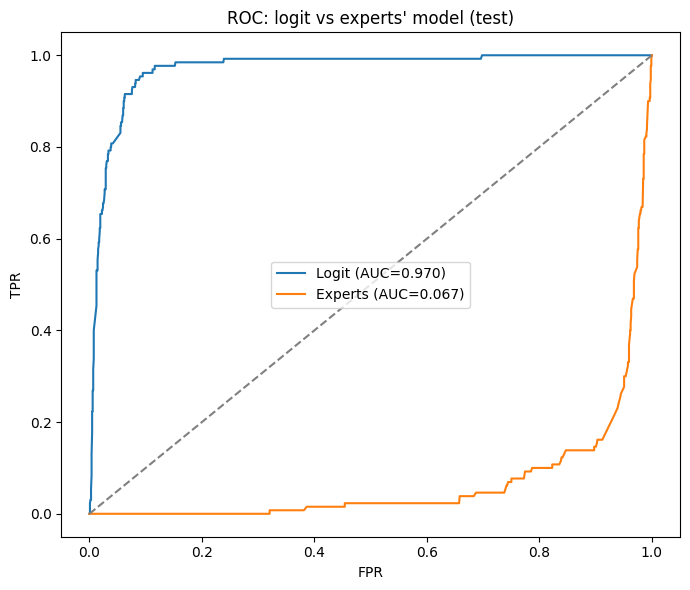

In [10]:
# Discrimination: logit vs experts
p_logit = logit.predict(X_test)                       # PD from the logistic model

y_t, p_log, p_exp = y_test[valid], p_logit[valid], pd_expert[valid]

auc_logit  = roc_auc_score(y_t, p_log)
auc_expert = roc_auc_score(y_t, p_exp)                # = AUC(Score), since the logistic map is monotone

print(f"Logit   : AUC = {auc_logit:.4f} | Gini = {2*auc_logit-1:.4f}")
print(f"Experts : AUC = {auc_expert:.4f} | Gini = {2*auc_expert-1:.4f}")
# AUC < 0.5 -> the ranking is inverted (higher PD assigned to healthier firms).
print(f"Experts (orientation-corrected): AUC = {max(auc_expert, 1-auc_expert):.4f}")

fpr_l, tpr_l, _ = roc_curve(y_t, p_log)
fpr_e, tpr_e, _ = roc_curve(y_t, p_exp)
plt.figure(figsize=(7, 6))
plt.plot(fpr_l, tpr_l, label=f"Logit (AUC={auc_logit:.3f})")
plt.plot(fpr_e, tpr_e, label=f"Experts (AUC={auc_expert:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC: logit vs experts' model (test)")
plt.legend(); plt.tight_layout(); plt.show()

### 6.3 Calibration and Brier score

Brier scores plus a reliability curve (predicted PD vs observed frequency by risk decile).

Brier  logit   = 0.0413
Brier  experts = 0.8810  (higher = worse)


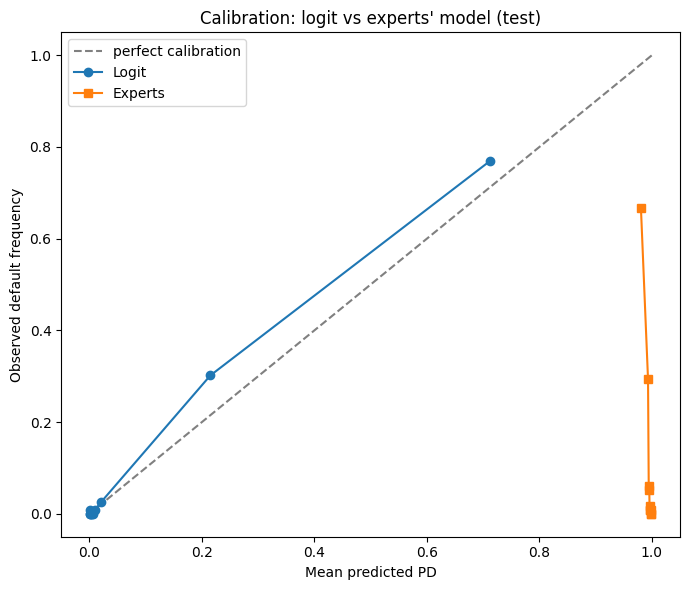

In [11]:
# Calibration and Brier score
# Brier = mean squared error of PD; lower is better (combines discrimination + calibration).
brier_logit  = np.mean((np.asarray(p_log) - np.asarray(y_t)) ** 2)
brier_expert = np.mean((np.asarray(p_exp) - np.asarray(y_t)) ** 2)
print(f"Brier  logit   = {brier_logit:.4f}")
print(f"Brier  experts = {brier_expert:.4f}  (higher = worse)")

# Calibration curve: mean predicted PD vs observed frequency, by risk decile
def calibration_points(p, y, q=10):
    d = pd.DataFrame({"p": np.asarray(p), "y": np.asarray(y)})
    d["bucket"] = pd.qcut(d["p"].rank(method="first"), q, labels=False)
    g = d.groupby("bucket").agg(pred=("p", "mean"), obs=("y", "mean"))
    return g["pred"], g["obs"]

pl_, ol_ = calibration_points(p_log, y_t)
pe_, oe_ = calibration_points(p_exp, y_t)
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
plt.plot(pl_, ol_, "o-", label="Logit")
plt.plot(pe_, oe_, "s-", label="Experts")
plt.xlabel("Mean predicted PD"); plt.ylabel("Observed default frequency")
plt.title("Calibration: logit vs experts' model (test)")
plt.legend(); plt.tight_layout(); plt.show()

## 7. Segmentation analysis by GROUP_FLAG

Does splitting the portfolio by holding-group membership help? For each `GROUP_FLAG` segment we
compare the overall model against a bespoke model refitted on that segment alone.

In [12]:
# Segmentation: overall model vs bespoke models
def gini(y, p):
    return 2 * roc_auc_score(y, p) - 1

def fit_logit(Xtr, ytr):
    # Drop within-segment constant columns (except const) and fit logit
    keep = [c for c in Xtr.columns if c == "const" or Xtr[c].nunique() > 1]
    try:
        m = sm.Logit(ytr, Xtr[keep]).fit(disp=0)
    except Exception:
        m = sm.Logit(ytr, Xtr[keep]).fit(method="bfgs", maxiter=200, disp=0)
    return m, keep

segments = sorted(train["GROUP_FLAG"].unique())     # [0, 1]
bespoke_models = {}
rows = []
for g in segments:
    tr = (train["GROUP_FLAG"] == g).values
    te = (test["GROUP_FLAG"]  == g).values
    Xtr_g, ytr_g = X_train[tr], y_train[tr]
    Xte_g, yte_g = X_test[te],  y_test[te]

    g_overall = gini(yte_g, logit.predict(Xte_g))   # overall model on this segment
    m_g, cols_g = fit_logit(Xtr_g, ytr_g)            # bespoke model (this segment only)
    bespoke_models[g] = (m_g, cols_g)
    g_bespoke = gini(yte_g, m_g.predict(Xte_g[cols_g]))

    rows.append({
        "GROUP_FLAG": g,
        "n_train": int(tr.sum()), "n_test": int(te.sum()),
        "DR_train": round(float(ytr_g.mean()), 3),
        "Gini_overall": round(g_overall, 4),
        "Gini_bespoke": round(g_bespoke, 4),
        "delta": round(g_bespoke - g_overall, 4),
    })

seg = pd.DataFrame(rows)
print(seg.to_markdown(index=False))
print(f"\nOverall model on the full test set: Gini = {gini(y_test, logit.predict(X_test)):.4f}")

|   GROUP_FLAG |   n_train |   n_test |   DR_train |   Gini_overall |   Gini_bespoke |   delta |
|-------------:|----------:|---------:|-----------:|---------------:|---------------:|--------:|
|            0 |      1723 |      398 |      0.094 |         0.9504 |         0.9504 |   0     |
|            1 |      2915 |      765 |      0.091 |         0.9344 |         0.9314 |  -0.003 |

Overall model on the full test set: Gini = 0.9395


### 7.1 Coefficient comparison across segments

Side-by-side coefficients of the overall model and the two segment models.

In [13]:
# Coefficient comparison: overall vs segments
coef = pd.DataFrame({"overall": logit.params})
for g, (m_g, _) in bespoke_models.items():
    coef[f"segment_{g}"] = m_g.params
print(coef.round(3).to_markdown())
# Large coefficient differences across segments would argue FOR bespoke models (firms behave
# differently); similar coefficients -> a single overall model is sufficient.

|                           |   overall |   segment_0.0 |   segment_1.0 |
|:--------------------------|----------:|--------------:|--------------:|
| const                     |    -2.232 |        -2.011 |        -2.315 |
| INDUSTRY_woe              |     0.747 |         0.759 |         0.832 |
| SHORT_TERM_LIQUIDITY_woe  |     0.247 |         0.431 |         0.168 |
| PROFITABILITY_woe         |     0.19  |         0.079 |         0.246 |
| PRODUCT_DEMAND_woe        |     0.743 |         0.965 |         0.653 |
| Number_of_credits_woe     |     1.15  |         1.243 |         1.124 |
| OWNERS_MANAGEMENT_woe     |     0.282 |         0.155 |         0.307 |
| MEDIUM_TERM_LIQUIDITY_woe |     0.056 |        -0.091 |         0.13  |


## 8. Model comparison & validation metrics

A consolidated view of all four models on the test set, followed by discrimination, calibration
and goodness-of-fit diagnostics.

### 8.1 Accuracy and Gini (test)

Accuracy at a 0.5 cutoff and Gini for each model, side by side.

| model   |   accuracy |    gini |
|:--------|-----------:|--------:|
| Logit   |     0.9441 |  0.9395 |
| Probit  |     0.9441 |  0.9393 |
| LPM     |     0.9347 |  0.9353 |
| Experts |     0.1118 | -0.8653 |


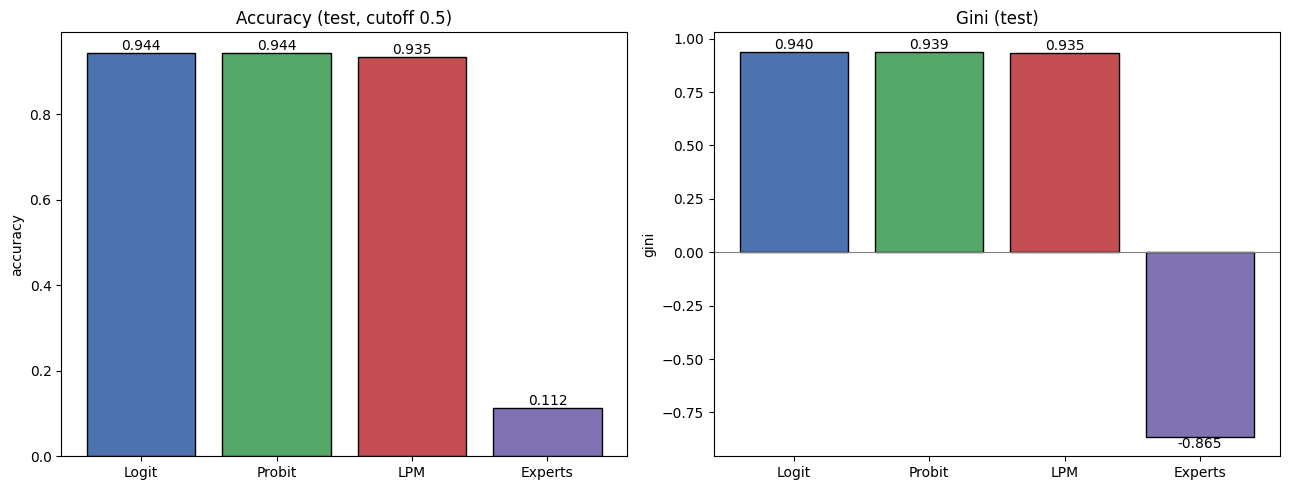

In [14]:
# Model comparison: Accuracy and Gini on the test set
# The four models built earlier + two test-set metrics:
# Accuracy@0.5 (as in the confusion matrices) and Gini = 2*AUC - 1 (discrimination).
THRESHOLD = 0.5

# Predictions recomputed from scratch (p_te gets overwritten in later cells)
preds = {
    "Logit":    logit.predict(X_test),
    "Probit":   probit.predict(X_test),
    "LPM":      lpm.predict(X_test),
    "Experts": pd_expert,
}

mask = valid   # common set of rows

results = []
for name, p in preds.items():
    p_m, y_m = p[mask], y_test[mask]
    acc = ((p_m >= THRESHOLD).astype(int) == y_m).mean()
    auc = roc_auc_score(y_m, p_m)
    results.append({"model": name, "accuracy": acc, "gini": 2 * auc - 1})

comp = pd.DataFrame(results).set_index("model")
print(comp.round(4).to_markdown())
# Note: the experts' Gini is negative (inverted ranking); accuracy@0.5 is dominated by the
# base default rate (~10%), so it is not a discriminating metric here.

# --- Side-by-side bar charts: Accuracy and Gini ---
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
for a, metric, title in zip(ax, ["accuracy", "gini"],
                            ["Accuracy (test, cutoff 0.5)", "Gini (test)"]):
    bars = a.bar(comp.index, comp[metric], color=colors, edgecolor="black")
    a.set_title(title); a.set_ylabel(metric); a.axhline(0, color="grey", linewidth=.8)
    for b in bars:
        h = b.get_height()
        a.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}",
               ha="center", va="bottom" if h >= 0 else "top", fontsize=10)
plt.tight_layout(); plt.show()

### 8.2 Discrimination: KS and a bootstrap CI for Gini

Assemble a common evaluation frame, then compare models with the Kolmogorov–Smirnov statistic
and a paired bootstrap confidence interval for Gini (is the logit's edge over probit real?).

In [15]:
# Final assessment: setup
# Predictions of the four models on the test set, on a COMMON set of rows (the 'valid' mask);
# recomputed from scratch because p_te gets overwritten in later cells.
from scipy.stats import ks_2samp
RNG = np.random.default_rng(RANDOM_STATE)

preds = {
    "Logit":    logit.predict(X_test)[valid].to_numpy(),
    "Probit":   probit.predict(X_test)[valid].to_numpy(),
    "LPM":      lpm.predict(X_test)[valid].to_numpy(),
    "Experts": pd_expert[valid].to_numpy(),
}
y_eval = y_test[valid].to_numpy().astype(int)
print(f"Evaluating on {len(y_eval)} test rows | default rate = {y_eval.mean():.3f}")

def gini_score(y, p):
    return 2 * roc_auc_score(y, p) - 1

def ks_score(y, p):
    # KS = max distance between bad/good score distributions; independent of model orientation
    return ks_2samp(p[y == 1], p[y == 0]).statistic

Evaluating on 1163 test rows | default rate = 0.112


| model   |    Gini |   CI_low |   CI_high |     KS |
|:--------|--------:|---------:|----------:|-------:|
| Logit   |  0.9395 |   0.9117 |    0.9627 | 0.8667 |
| Probit  |  0.9393 |   0.9107 |    0.9626 | 0.8658 |
| LPM     |  0.9353 |   0.9035 |    0.9617 | 0.8705 |
| Experts | -0.8653 |  -0.9029 |   -0.822  | 0.7589 |

Gini(Logit) - Gini(Probit) = +0.0002 | 95% CI [-0.0007, +0.0011]
-> CI contains 0: no significant difference.


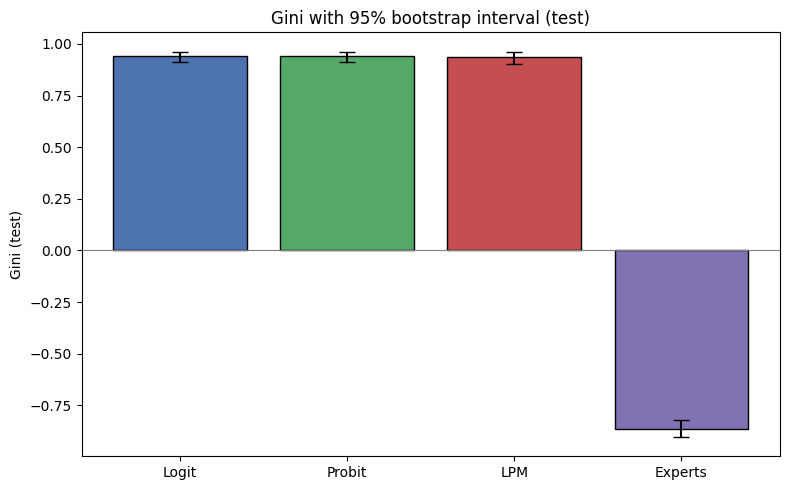

In [16]:
# Discrimination: KS + bootstrap confidence interval for Gini
N_BOOT, ALPHA = 2000, 0.05
pos, neg = np.where(y_eval == 1)[0], np.where(y_eval == 0)[0]

# PAIRED bootstrap: the same resampled rows for every model (stratified by class)
boot = {m: np.empty(N_BOOT) for m in preds}
for b in range(N_BOOT):
    idx = np.concatenate([RNG.choice(pos, pos.size, replace=True),
                          RNG.choice(neg, neg.size, replace=True)])
    yb = y_eval[idx]
    for m, p in preds.items():
        boot[m][b] = gini_score(yb, p[idx])

rows = []
for m, p in preds.items():
    lo, hi = np.percentile(boot[m], [100*ALPHA/2, 100*(1-ALPHA/2)])
    rows.append({"model": m, "Gini": gini_score(y_eval, p),
                 "CI_low": lo, "CI_high": hi, "KS": ks_score(y_eval, p)})
disc = pd.DataFrame(rows).set_index("model")
print(disc.round(4).to_markdown())

# Is the logit edge over probit real, or within noise?
dlo, dhi = np.percentile(boot["Logit"] - boot["Probit"], [2.5, 97.5])
dpt = gini_score(y_eval, preds["Logit"]) - gini_score(y_eval, preds["Probit"])
print(f"\nGini(Logit) - Gini(Probit) = {dpt:+.4f} | 95% CI [{dlo:+.4f}, {dhi:+.4f}]")
print("-> CI contains 0: no significant difference." if dlo <= 0 <= dhi
      else "-> CI excludes 0: significant difference.")

# Plot: Gini with asymmetric 95% bootstrap whiskers
plt.figure(figsize=(8, 5))
err = np.array([disc["Gini"] - disc["CI_low"], disc["CI_high"] - disc["Gini"]])
plt.bar(disc.index, disc["Gini"], yerr=err, capsize=6,
        color=["#4C72B0", "#55A868", "#C44E52", "#8172B3"], edgecolor="black")
plt.axhline(0, color="grey", lw=.8)
plt.ylabel("Gini (test)"); plt.title("Gini with 95% bootstrap interval (test)")
plt.tight_layout(); plt.show()
# Note: KS ignores orientation - the experts score has high KS despite Gini < 0 (inverted
# ranking). We therefore base the decision on signed Gini and calibration, not KS alone.

### 8.3 Calibration: reliability diagrams + Brier

Per-model reliability diagrams and Brier scores, including the share of out-of-[0,1] predictions.

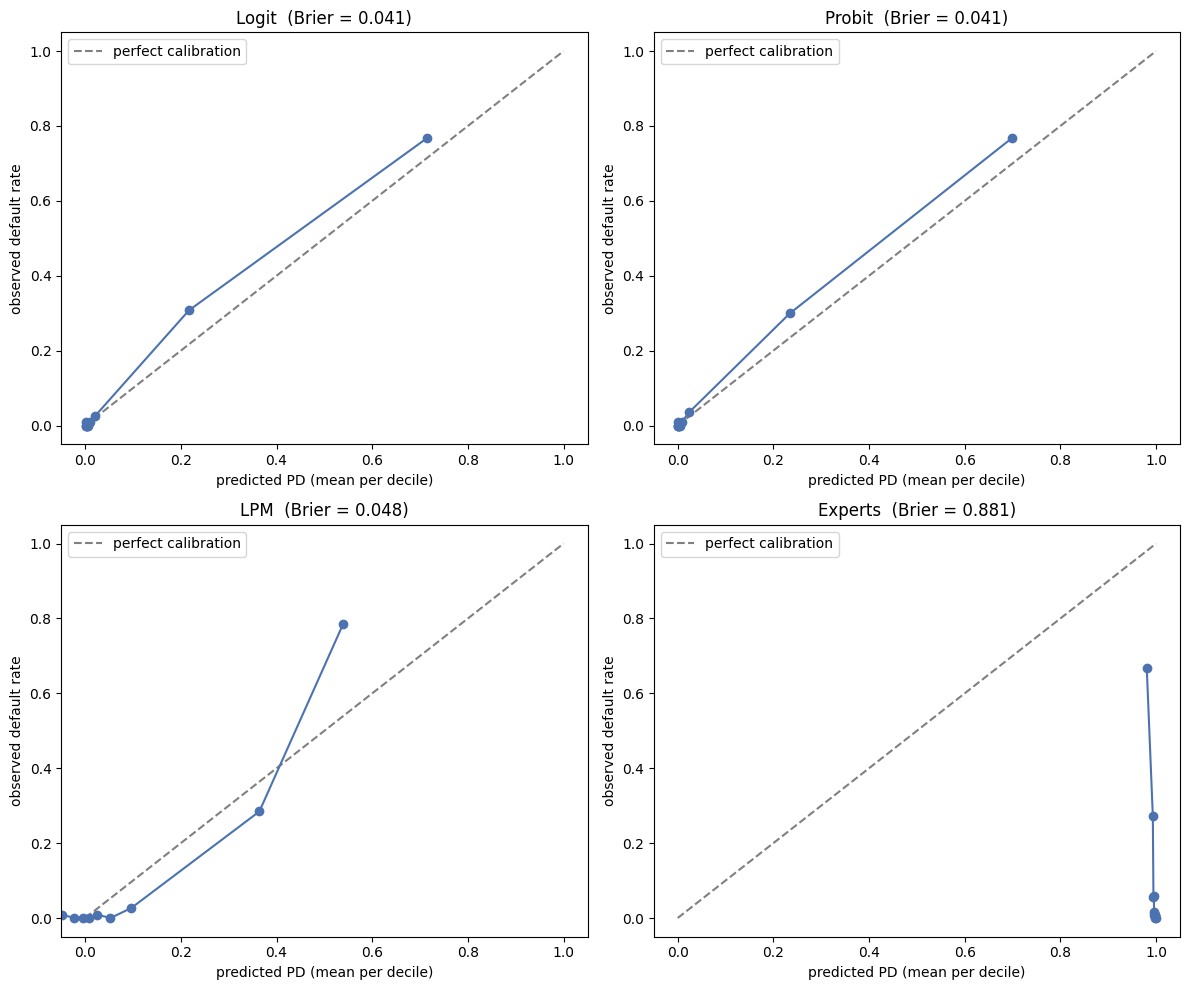

| model   |   Brier |   mean_PD |   obs_default_rate |   frac_outside_[0,1]_% |
|:--------|--------:|----------:|-------------------:|-----------------------:|
| Logit   |  0.0413 |    0.0978 |             0.1118 |                 0      |
| Probit  |  0.0413 |    0.097  |             0.1118 |                 0      |
| LPM     |  0.0484 |    0.0929 |             0.1118 |                37.0593 |
| Experts |  0.881  |    0.9947 |             0.1118 |                 0      |


In [17]:
# Calibration: reliability diagrams + Brier
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
cal_rows = []
for ax, (m, p) in zip(axes.ravel(), preds.items()):
    brier = np.mean((p - y_eval) ** 2)
    cal_rows.append({"model": m, "Brier": brier, "mean_PD": p.mean(),
                     "obs_default_rate": y_eval.mean(),
                     "frac_outside_[0,1]_%": 100 * np.mean((p < 0) | (p > 1))})
    d = pd.DataFrame({"p": p, "y": y_eval})
    d["bin"] = pd.qcut(d["p"], 10, duplicates="drop")
    g = d.groupby("bin", observed=True).agg(pred=("p", "mean"), obs=("y", "mean"))
    ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
    ax.plot(g["pred"], g["obs"], "o-", color="#4C72B0")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{m}  (Brier = {brier:.3f})")
    ax.set_xlabel("predicted PD (mean per decile)"); ax.set_ylabel("observed default rate")
    ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

cal = pd.DataFrame(cal_rows).set_index("model")
print(cal.round(4).to_markdown())
# Good calibration = points on the diagonal and a low Brier. The LPM reveals a % of
# predictions outside [0,1]; the experts' mean PD ~0.99 vs observed ~0.11 (badly miscalibrated).

### 8.4 Goodness of fit & parsimony: AIC / BIC

AIC, BIC and McFadden pseudo-R² — comparable between the logit and probit only.

In [18]:
# Goodness of fit & parsimony: AIC / BIC
# AIC/BIC are comparable ONLY between logit and probit (same Bernoulli likelihood, same data,
# same number of parameters). The LPM (OLS) has a Gaussian likelihood - different scale; the
# experts' model is not estimated, so AIC/BIC do not exist for it.
fit_tbl = pd.DataFrame([
    {"model": name, "n_params": len(mdl.params), "logLik": mdl.llf,
     "AIC": mdl.aic, "BIC": mdl.bic, "pseudoR2_McFadden": mdl.prsquared}
    for name, mdl in [("Logit", logit), ("Probit", probit)]
]).set_index("model")
print(fit_tbl.round(3).to_markdown())
print(f"\nLower AIC/BIC = better fit penalized for complexity. Lowest AIC: {fit_tbl['AIC'].idxmin()}.")

| model   |   n_params |   logLik |     AIC |     BIC |   pseudoR2_McFadden |
|:--------|-----------:|---------:|--------:|--------:|--------------------:|
| Logit   |          8 | -598.636 | 1213.27 | 1264.81 |               0.581 |
| Probit  |          8 | -592.354 | 1200.71 | 1252.24 |               0.585 |

Lower AIC/BIC = better fit penalized for complexity. Lowest AIC: Probit.


## 9. Summary & notes

**Pipeline.** Data-quality assessment → customer-history features → customer-level train/test
split → WoE binning with IV- and correlation-based selection (all fitted on train) → logistic,
probit and linear models, plus an experts'-scorecard benchmark and a segmentation check.

**Model choice.** Logit and probit are statistically indistinguishable here — the 95% bootstrap
confidence interval for their Gini difference contains zero — so the logit is kept for its
log-odds interpretability and regulatory familiarity. The linear probability model is rejected
because a large share of its predictions fall outside [0, 1]. The experts' fixed formula is both
badly miscalibrated (mean PD ≈ 0.99 against an observed default rate ≈ 0.11) and inverted in its
ranking on this 10–90 scale.

**On the headline performance.** The reported test Gini (≈ 0.94) and the Information Values
(2–5 for the expert dimensions) are far above what a real-world corporate PD model achieves
(typically Gini ≈ 0.4–0.7). This reflects the nature of the predictors: the six dimensions are
*expert assessment scores* very strongly aligned with the target rather than raw financials —
the probit's quasi-separation warning points to the same thing. The figures should therefore be
read as a property of this (teaching) dataset, not as out-of-sample performance expected in
production. Natural ways to stress-test it would be an out-of-time split (e.g. train ≤ 2006,
test 2007–2008), a Population Stability Index (PSI) check across years, and rebuilding the model
on raw financial ratios.